# Section 5: Petroleum Tax as a Pigou-Style Tax
**Member 3** — Work on this section, then integrate into the main notebook.

**Your responsibility:** Tax decomposition (government vs firms), Ramsey optimal taxation analysis, non-distortionary profit tax vs distortionary per-unit tax comparison, distributional analysis (who gains?). You should be able to explain: why profit taxes don't distort supply, the Ramsey inverse elasticity rule, and why Norway's 78% rate is efficient.

---

*The setup cells below (imports + solvers) are shared across all members.*

# Who Gains When Gas Prices Surge?
## A Welfare Analysis of Norway's Gas Economy Under the Ukraine War Supply Shock

**EBA3650 — Quantitative Economics**
BI Norwegian Business School | Spring 2026 | Group of 4

### Research Question

The 2022 Russian invasion of Ukraine triggered one of the largest energy supply shocks in recent history. As Russian pipeline gas to Europe was curtailed — from roughly 155 bcm/year to under 30 bcm — European gas prices surged to unprecedented levels, with TTF spot prices exceeding EUR 300/MWh in August 2022.

Norway — as Europe's now-largest pipeline gas supplier — found itself at the centre of this shift.

This project asks: **Does Norway benefit from the war-induced gas price surge, and if so, who within Norway captures the gains?**

We decompose the welfare effects across three agents:
1. **Gas-producing firms** — producer surplus gain
2. **Norwegian consumers** — welfare loss from higher energy prices
3. **The Norwegian state** — government revenue gain via the 78% petroleum tax

We aggregate these into a net welfare measure and test robustness through sensitivity analysis across key structural parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Custom Numerical Solvers

We implement the secant method and Newton's method from Sessions 2–3 as our primary equation solvers, then verify results with `scipy.optimize`.

In [2]:
# Secant method for equation solving (Session 3)
def our_secant_solver(funcname, x1, x2, arglist):
    y1 = funcname(x1, arglist)
    for _ in range(200):
        y2 = funcname(x2, arglist)
        if abs(y1) < 1e-10:
            return x1
        x_new = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1 = x2
        y1 = y2
        x2 = x_new
    return x2

# Newton's method with numerical derivatives (Session 3)
def our_newton_solver(funcname, startvalue, arglist):
    current = startvalue
    fval = funcname(current, arglist)
    grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    while abs(fval) > 1e-10:
        current = current - fval / grad
        fval = funcname(current, arglist)
        grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    return current

# Quick test on a known equation: x^2 - 4 = 0 => x = 2
def test_eq(x, args):
    return x**2 - 4

print(f"Secant solver:  x = {our_secant_solver(test_eq, 1, 3, None):.8f}")
print(f"Newton solver:  x = {our_newton_solver(test_eq, 3, None):.8f}")
print("Both solvers verified: x^2 = 4 => x = 2.0")

Secant solver:  x = 2.00000000
Newton solver:  x = 2.00000000
Both solvers verified: x^2 = 4 => x = 2.0


In [3]:
# === Values from Section 3 (Member 1's work) ===
# These will come from the full notebook. For now, hardcoded so you can work independently.

P0 = 20.0            # pre-war gas price (EUR/MWh)
Q0 = 4000.0          # pre-war quantity (TWh/yr)
eps_d = -0.3
eps_s = 0.35
A_d = Q0 / P0**eps_d
A_s = Q0 / P0**eps_s
delta = 0.40
norway_share = 0.25
A_NO = norway_share * A_s

def demand(price, level, el):
    return level * price**el

def supply(price, level, el):
    return level * price**el

def inverse_supply(q, level, el):
    return (q / level)**(1.0 / el)

def ps_analytical(eq_price, A, eps):
    Q = supply(eq_price, A, eps)
    cost_integral = A**(-1/eps) * Q**(1 + 1/eps) / (1 + 1/eps)
    return eq_price * Q - cost_integral

# Solve for post-shock price
P1_scipy = opt.bisect(lambda p: demand(p, A_d, eps_d) - supply(p, (1-delta)*A_s, eps_s), 1, 500)
Q1_scipy = demand(P1_scipy, A_d, eps_d)
PS_pre_analytical = ps_analytical(P0, A_NO, eps_s)
PS_post_analytical = ps_analytical(P1_scipy, A_NO, eps_s)
delta_PS = PS_post_analytical - PS_pre_analytical
scale = 1e3

print(f'Post-shock price: {P1_scipy:.2f} EUR/MWh')
print(f'Delta PS: {delta_PS/scale:.2f} bn EUR')

# === Values from Section 4 (Member 2's work) ===
passthrough = 0.5
eta_c = 0.3
I_household = 50000.0
n_households = 2.4e6
p_energy_pre = P0 * passthrough
p_energy_post = P1_scipy * passthrough
energy_spend_target = 2000.0
g_target = energy_spend_target / p_energy_pre
B_consumer = p_energy_pre * g_target**(1.0 / eta_c)

def utility_ql(g, y, B, eta):
    return y + B / (1 - 1/eta) * g**(1 - 1/eta)

def demand_energy(price, B, eta):
    return (B / price)**eta

def indirect_utility_ql(income, price, B, eta):
    g = demand_energy(price, B, eta)
    y = income - price * g
    return utility_ql(g, y, B, eta)

V_pre = indirect_utility_ql(I_household, p_energy_pre, B_consumer, eta_c)
V_post = indirect_utility_ql(I_household, p_energy_post, B_consumer, eta_c)
CV_total = (V_pre - V_post) * n_households

print(f'Consumer welfare loss: {CV_total/1e9:.3f} bn EUR')


Post-shock price: 43.89 EUR/MWh
Delta PS: 27.99 bn EUR
Consumer welfare loss: 5.029 bn EUR


## 5. Petroleum Tax as a Pigou-Style Tax

Norway's petroleum tax system imposes an effective marginal tax rate of approximately **78%** on upstream petroleum profits (including gas production). This functions as a near-confiscatory tax on economic rents from resource extraction.

We decompose the producer surplus into:
- **Government revenue:** $G = \tau \cdot PS$
- **Firm profit (after tax):** $\Pi = (1 - \tau) \cdot PS$

where $\tau = 0.78$ is the petroleum tax rate.

In [4]:
# Petroleum tax decomposition
tau = 0.78  # effective petroleum tax rate

# Pre-war
G_pre = tau * PS_pre_analytical
profit_pre = (1 - tau) * PS_pre_analytical

# Post-shock
G_post = tau * PS_post_analytical
profit_post = (1 - tau) * PS_post_analytical

# Changes
delta_G = G_post - G_pre
delta_profit = profit_post - profit_pre

print(f"=== Petroleum Tax Decomposition (tau = {tau:.0%}) ===")
print(f"")
print(f"{'':>30s} {'Pre-war':>12s} {'Post-shock':>12s} {'Change':>12s}")
print(f"{'─'*66}")
print(f"{'Gross producer surplus':>30s} {PS_pre_analytical/scale:>12.2f} {PS_post_analytical/scale:>12.2f} {delta_PS/scale:>+12.2f}")
print(f"{'Government revenue (78%)':>30s} {G_pre/scale:>12.2f} {G_post/scale:>12.2f} {delta_G/scale:>+12.2f}")
print(f"{'Firm profit (22%)':>30s} {profit_pre/scale:>12.2f} {profit_post/scale:>12.2f} {delta_profit/scale:>+12.2f}")
print(f"{'Consumer welfare loss':>30s} {'':>12s} {'':>12s} {-CV_total/1e9:>+12.3f}")
print(f"{'─'*66}")
print(f"{'(All values in billion EUR)':>30s}")

=== Petroleum Tax Decomposition (tau = 78%) ===

                                    Pre-war   Post-shock       Change
──────────────────────────────────────────────────────────────────
        Gross producer surplus        14.81        42.80       +27.99
      Government revenue (78%)        11.56        33.39       +21.83
             Firm profit (22%)         3.26         9.42        +6.16
         Consumer welfare loss                                 -5.029
──────────────────────────────────────────────────────────────────
   (All values in billion EUR)


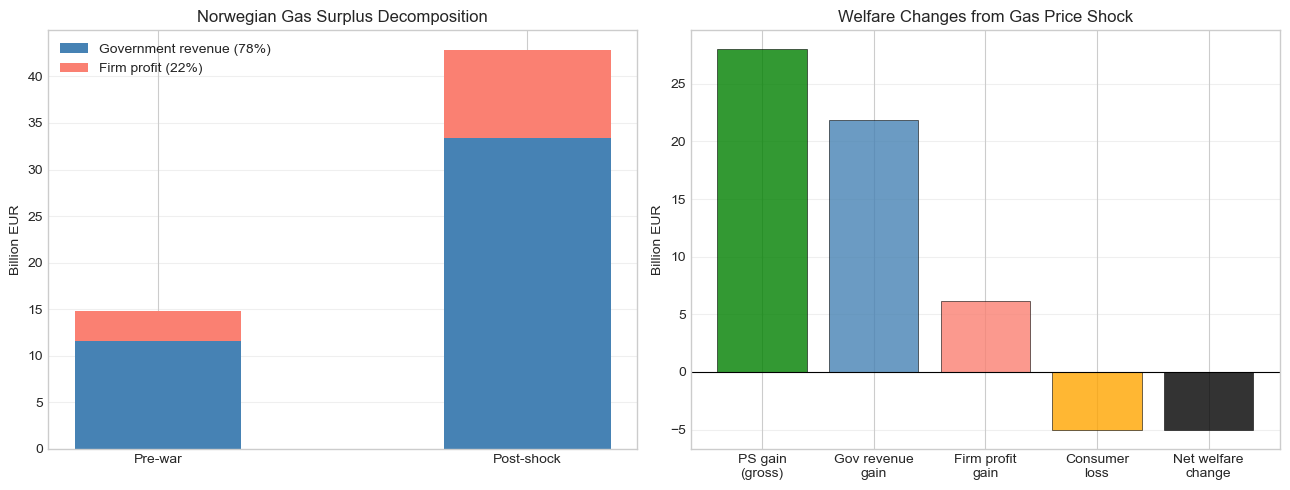

In [5]:
# Stacked bar chart: surplus decomposition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: absolute values pre vs post
labels = ['Pre-war', 'Post-shock']
gov_vals = [G_pre/scale, G_post/scale]
firm_vals = [profit_pre/scale, profit_post/scale]

x_pos = np.arange(len(labels))
width = 0.45

ax1.bar(x_pos, gov_vals, width, label='Government revenue (78%)', color='steelblue')
ax1.bar(x_pos, firm_vals, width, bottom=gov_vals, label='Firm profit (22%)', color='salmon')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Billion EUR')
ax1.set_title('Norwegian Gas Surplus Decomposition')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Right panel: changes (waterfall-style)
changes = ['PS gain\n(gross)', 'Gov revenue\ngain', 'Firm profit\ngain', 'Consumer\nloss', 'Net welfare\nchange']
net_W = delta_G + delta_profit - CV_total
values = [delta_PS/scale, delta_G/scale, delta_profit/scale, -CV_total/1e9, net_W/1e9]
colors_bar = ['green', 'steelblue', 'salmon', 'orange', 'black']

ax2.bar(changes, values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Changes from Gas Price Shock')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.1 Who Gains? Distributional Analysis

The research question asks not just *whether* Norway benefits, but **who within Norway captures the gains**. The answer is strikingly uneven:

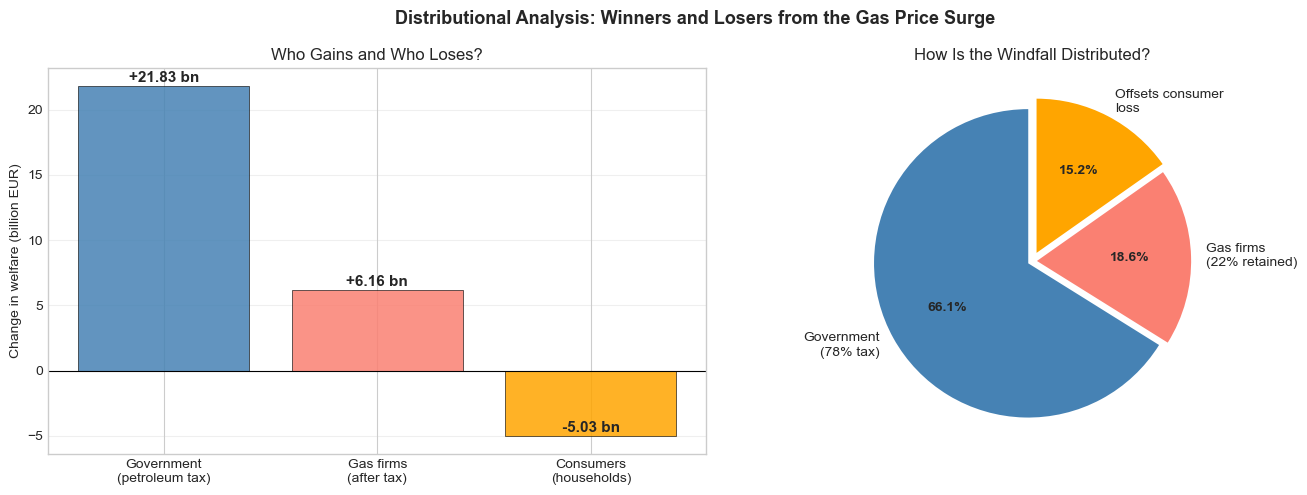

The gross producer surplus windfall is 27.99 bn EUR.

  → Government captures 21.83 bn EUR (78% of windfall)
  → Gas firms retain    6.16 bn EUR (22% of windfall)
  → Consumers lose      5.03 bn EUR

The government is the DOMINANT winner — receiving 78% of the windfall.
Consumer losses are 18.0% of the gross windfall — easily offset.

If the government redistributed just 5.03 bn of its 21.83 bn gain,
every household could be fully compensated (2096 EUR each),
and the state would STILL retain 16.80 bn EUR.


In [6]:
# === WHO GAINS? — Distributional breakdown ===

# Compute gains/losses per agent
agents = ['Government\n(petroleum tax)', 'Gas firms\n(after tax)', 'Consumers\n(households)']
agent_changes = [delta_G/scale, delta_profit/scale, -CV_total/1e9]
agent_colors = ['steelblue', 'salmon', 'orange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute gains/losses per agent
bars = ax1.bar(agents, agent_changes, color=agent_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars, agent_changes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:+.2f} bn', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylabel('Change in welfare (billion EUR)')
ax1.set_title('Who Gains and Who Loses?')
ax1.grid(True, alpha=0.3, axis='y')

# Right: pie chart of the WINDFALL (positive gains only)
# How is the gross PS windfall distributed?
pie_labels = [f'Government\n({tau:.0%} tax)', f'Gas firms\n({1-tau:.0%} retained)', f'Offsets consumer\nloss']
pie_values = [delta_G/scale, delta_profit/scale, CV_total/1e9]
pie_colors = ['steelblue', 'salmon', 'orange']
explode = (0.03, 0.03, 0.06)

wedges, texts, autotexts = ax2.pie(pie_values, labels=pie_labels, colors=pie_colors,
                                    autopct='%1.1f%%', startangle=90, explode=explode,
                                    textprops={'fontsize': 10})
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('How Is the Windfall Distributed?')

plt.suptitle('Distributional Analysis: Winners and Losers from the Gas Price Surge',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the story
print(f"The gross producer surplus windfall is {delta_PS/scale:.2f} bn EUR.")
print(f"")
print(f"  → Government captures {delta_G/scale:.2f} bn EUR ({tau:.0%} of windfall)")
print(f"  → Gas firms retain    {delta_profit/scale:.2f} bn EUR ({1-tau:.0%} of windfall)")
print(f"  → Consumers lose      {CV_total/1e9:.2f} bn EUR")
print(f"")
print(f"The government is the DOMINANT winner — receiving {delta_G/delta_PS*100:.0f}% of the windfall.")
print(f"Consumer losses are {CV_total/1e9/(delta_PS/scale)*100:.1f}% of the gross windfall — easily offset.")
print(f"")
print(f"If the government redistributed just {CV_total/1e9:.2f} bn of its {delta_G/scale:.2f} bn gain,")
print(f"every household could be fully compensated ({CV_total/n_households:.0f} EUR each),")
print(f"and the state would STILL retain {(delta_G/scale - CV_total/1e9):.2f} bn EUR.")

**Key insight:** The Norwegian state is overwhelmingly the biggest winner. The 78% petroleum tax channels most of the windfall to the government. Gas firms also gain, but retain only 22% of the surplus increase. Consumers are the clear losers — but their total loss is small relative to the government's gain.

This means the government has more than enough fiscal space to fully compensate all households and *still* come out far ahead. Whether this actually happens is a political question, not an economic one — but the *potential* for a Pareto improvement exists.

### 5.2 Ramsey Optimal Taxation: Why 78% Is Not Distortionary

A key insight from optimal taxation theory (Session 9) is the distinction between **rent taxes** and **per-unit taxes**:

- A **profits/rent tax** captures a share of surplus *without changing production decisions*. Since the tax is on profits (revenue minus costs), firms still maximise the same objective — the tax rate cancels from the first-order conditions. There is **no deadweight loss**.

- A **per-unit (excise) tax** creates a wedge between the price consumers pay and the price producers receive, causing underproduction and deadweight loss. The Ramsey rule says such taxes should be inversely proportional to elasticity.

Norway's 78% petroleum tax is a *profits tax*. It extracts most of the rent but does not distort the supply curve. This is why such a high rate is economically efficient.

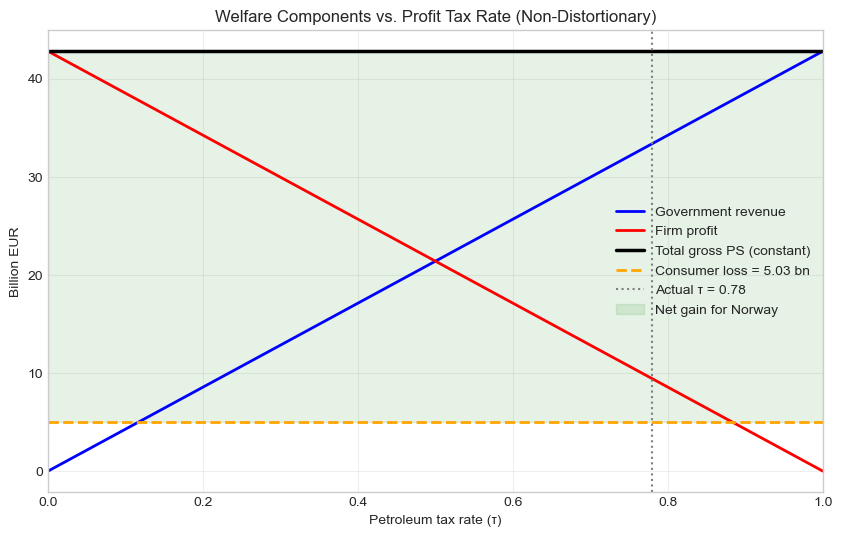

Total gross PS is constant at 42.80 bn EUR regardless of tax rate.
The tax only redistributes between government and firms — no DWL.


In [7]:
# Demonstrate: welfare components are INDEPENDENT of profit tax rate
# (because profit tax doesn't distort production)
tax_rates = np.linspace(0, 1.0, 200)
gov_rev_curve = np.zeros(200)
firm_prof_curve = np.zeros(200)
total_surplus_curve = np.zeros(200)

for i in range(200):
    t = tax_rates[i]
    gov_rev_curve[i] = t * PS_post_analytical / scale
    firm_prof_curve[i] = (1 - t) * PS_post_analytical / scale
    total_surplus_curve[i] = PS_post_analytical / scale  # constant!

plt.figure(figsize=(10, 6))
plt.plot(tax_rates, gov_rev_curve, '-b', linewidth=2, label='Government revenue')
plt.plot(tax_rates, firm_prof_curve, '-r', linewidth=2, label='Firm profit')
plt.plot(tax_rates, total_surplus_curve, '-k', linewidth=2.5, label='Total gross PS (constant)')
plt.axhline(y=CV_total/1e9, color='orange', linestyle='--', linewidth=2, label=f'Consumer loss = {CV_total/1e9:.2f} bn')
plt.axvline(x=0.78, color='gray', linestyle=':', linewidth=1.5, label='Actual τ = 0.78')
plt.fill_between(tax_rates, CV_total/1e9, total_surplus_curve, alpha=0.1, color='green', label='Net gain for Norway')
plt.xlabel('Petroleum tax rate (τ)')
plt.ylabel('Billion EUR')
plt.title('Welfare Components vs. Profit Tax Rate (Non-Distortionary)')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

print(f"Total gross PS is constant at {PS_post_analytical/scale:.2f} bn EUR regardless of tax rate.")
print(f"The tax only redistributes between government and firms — no DWL.")

### 5.3 Comparison: What If Norway Used a Per-Unit Tax Instead?

To illustrate why the profits tax design matters, we compute the hypothetical deadweight loss if Norway instead taxed gas production with a per-unit (excise) tax. A per-unit tax $t$ shifts the supply curve upward: firms require price $P + t$ to produce the same quantity.

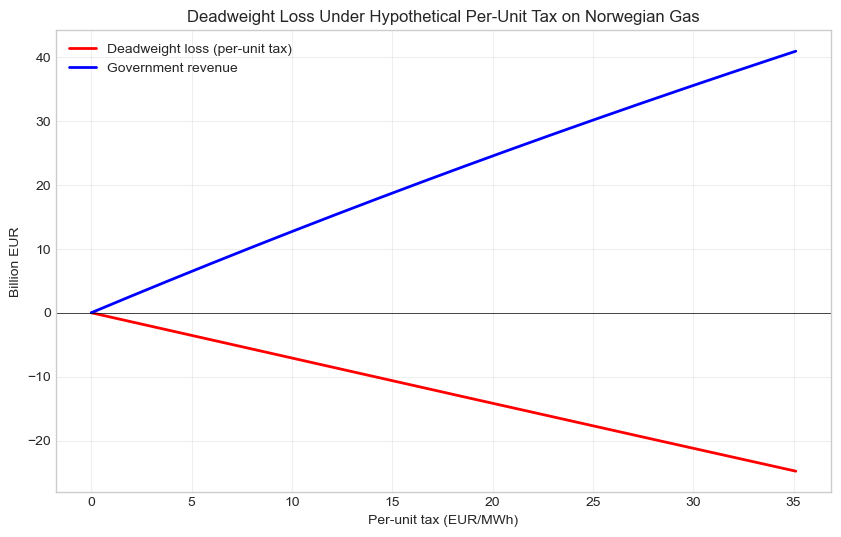

Under the actual profits tax: DWL = 0 (by design)
A per-unit tax would create increasing DWL as the rate rises.


In [8]:
# Hypothetical per-unit tax analysis (distortionary)
unit_taxes = np.linspace(0, P1_scipy * 0.8, 150)
welfare_unit = np.zeros(150)
dwl_unit = np.zeros(150)
gov_rev_unit = np.zeros(150)

# Reference: welfare without any tax (just the shock)
W_notax = PS_post_analytical / scale - CV_total / 1e9

for i in range(150):
    t = unit_taxes[i]
    # With per-unit tax t on producers: supply curve shifts up
    # Producers receive (P - t), so supply = A_s_post * (P - t)^eps_s
    # Market clearing: demand(P) = supply((P-t))
    def excess_with_unit_tax(price):
        if price <= t + 0.01:
            return 1e10  # no supply at negative producer price
        return demand(price, A_d, eps_d) - supply(price - t, (1 - delta) * A_s, eps_s)

    try:
        P_tax = opt.bisect(excess_with_unit_tax, t + 0.02, 500)
        Q_tax = demand(P_tax, A_d, eps_d)
        Q_NO_tax = supply(P_tax - t, A_NO, eps_s)

        # Norwegian PS at producer price (P - t)
        ps_nor = ps_analytical(P_tax - t, A_NO, eps_s)
        # Government revenue from Norwegian production
        gov_rev_unit[i] = (t * Q_NO_tax) / scale

        welfare_unit[i] = ps_nor / scale + gov_rev_unit[i] - CV_total / 1e9
        dwl_unit[i] = W_notax - welfare_unit[i]
    except:
        welfare_unit[i] = np.nan
        dwl_unit[i] = np.nan
        gov_rev_unit[i] = np.nan

plt.figure(figsize=(10, 6))
plt.plot(unit_taxes, dwl_unit, '-r', linewidth=2, label='Deadweight loss (per-unit tax)')
plt.plot(unit_taxes, gov_rev_unit, '-b', linewidth=2, label='Government revenue')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.xlabel('Per-unit tax (EUR/MWh)')
plt.ylabel('Billion EUR')
plt.title('Deadweight Loss Under Hypothetical Per-Unit Tax on Norwegian Gas')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Under the actual profits tax: DWL = 0 (by design)")
print(f"A per-unit tax would create increasing DWL as the rate rises.")